Problems:
    - after a while, returns explode and oscilate between -7.5 and +7.5 until end of sample
    - when lambda is to low, one extreme beta estimate destabilizes the whole system and this extreme estimate carries over to future periods
    - when lambda is to high, all coefficients are penalized away
    - if the simulation does not explode, there is a timing issue, coefficients estimated in simulation and empirical are off by 1 day

What remains to do:

    - think about whether this makes sense
    - code a loop that tests a range of standard deviations and stores them along with n_active and r2

Fixed so far:

    - centered returns as in the empirical function
    - scaled topic matrix before LASSO and scaled back before giving to ALM


In [14]:
import os
import sys
from pathlib import Path

# Find repo root (folder containing both Empirical/ and Theory/) starting from cwd
current = Path.cwd().resolve()
repo_root = next(
    (p for p in [current, *current.parents] if (p / "Empirical").exists() and (p / "Theory").exists()),
    None,
 )
if repo_root is None:
    raise FileNotFoundError("Could not locate repository root containing 'Empirical' and 'Theory'.")

# Ensure estimation modules are importable by both Python runtime and Pylance
estimation_dir = repo_root / "Empirical" / "estimation"
if str(estimation_dir) not in sys.path:
    sys.path.insert(0, str(estimation_dir))

# Keep working directory aligned with existing script expectations
os.chdir(estimation_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit
from scipy.stats.mstats import winsorize

# Importing from your provided scripts
from stage1 import to_ar1_innovations, create_lagged_features
from grid_search import estimate_single_config_fast

In [15]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 1 # std dev of the dividend process
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
print(f"w: {w}, kappa: {kappa}")



# load topics
topics = pd.read_csv(repo_root / "Empirical" / "data" / "merged_return_topic_data.csv")
# keep only the relevant columns (those that conatin no numbers in their name)
topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
# set date as index
topics.set_index('date', inplace=True)
# extract innovations
topics = to_ar1_innovations(topics)
# delete first row since it will be all NaN after the AR(1) transformation
topics = topics.iloc[1:]

topics = topics.apply(lambda x: winsorize(x, limits=[0.01, 0.01]))

w: -0.4572244047433405, kappa: 1.5796116170264534


In [16]:
def multivariate_CGL_offline_lasso(X, sigma, kappa, w, rolling_window_size=20, lambda_lasso=0.01, correct_with_tanh=True, random_number=42, standardize=True, n_lags=1):
    
    T, K = X.shape
    X = np.asarray(X)
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    # --- NEW: Generate Lagged Features ---
    # We pad X with a row of zeros. Since `create_lagged_features_with_name` 
    # typically drops the last observation to align with a known target, 
    # padding ensures we retain the lag feature needed for the final t+1 prediction step.
    X_padded = np.vstack([X, np.zeros((1, K))])
    X_lagged, _ = create_lagged_features(X_padded, n_lags)
    n_features = X_lagged.shape[1]

    # MODIFIED: Ensure beta array can hold the expanded number of features
    beta_offline = np.zeros((T, n_features, 1))
    intercept_offline = np.zeros(T)
    r_offline = np.zeros(T)
    n_active = 0  
    predictions = np.zeros(T)
    np.random.seed(random_number)

    if standardize:
        scaler = StandardScaler()
        X_lagged = scaler.fit_transform(X_lagged)
    else:
        scaler = None
        X_lagged = X_lagged

    # MODIFIED: Adjust burn-in phase to account for n_lags
    r_offline[1:rolling_window_size + n_lags] = np.random.normal(0, sigma, rolling_window_size + n_lags - 1)

    # Initialize model outside loop for actual warm_start performance
    model = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42, warm_start=True)

    # MODIFIED: Start the loop after the burn-in and lag offset
    for t in range(rolling_window_size + n_lags, T):
        
        # MODIFIED: Extract the rolling window directly from the lagged feature matrix
        x_current = X_lagged[t - rolling_window_size - n_lags : t - n_lags, :] 
        r_offline_current = r_offline[t - rolling_window_size : t] 
        r_centered = r_offline_current - np.mean(r_offline_current)
    
        # Fit the model
        model.fit(x_current, r_centered)
        
        # Calculate rescaled coefficients and the implied intercept
        if standardize:
            coef = model.coef_ / scaler.scale_
            intercept = -np.dot(scaler.mean_, coef) 
        else:
            coef = model.coef_
            intercept = 0

        beta_offline[t-1] = coef.reshape(-1, 1)
        intercept_offline[t-1] = intercept
        n_active += np.count_nonzero(beta_offline[t-1])

        x_t_lagged = X_lagged[t + 1 - n_lags, :].reshape(1, -1)
        
        if standardize:
            x_t_scaled = scaler.transform(x_t_lagged)
            predictions[t] = model.predict(x_t_scaled)[0]
        else:
            predictions[t] = model.predict(x_t_lagged)[0]

        pred_t_minus_1 = predictions[t-1]
        pred_t_minus_2 = predictions[t-2]

        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_2 / w))) - 
                            np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_1 / w))) + 
                            np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp(pred_t_minus_2)) - 
                            np.log(1 - kappa * np.exp(pred_t_minus_1)) + 
                            np.random.normal(0, sigma)).item() 
    
    return beta_offline, r_offline, n_active

In [ ]:
# import numpy as np
# from sklearn.linear_model import Lasso
# from sklearn.preprocessing import StandardScaler

# # Note: Make sure your create_lagged_features function is imported or defined above this

# def multivariate_CGL_offline_lasso(X, sigma, kappa, w, rolling_window_size=20, lambda_lasso=0.01, correct_with_tanh=True, random_number=42, standardize=True, n_lags=1):
    
#     T, K = X.shape
#     X = np.asarray(X)
#     assert rolling_window_size < T, "rolling_window_size must be less than T"

#     # --- Generate Lagged Features ---
#     X_padded = np.vstack([X, np.zeros((1, K))])
#     X_lagged, _ = create_lagged_features(X_padded, n_lags)
#     n_features = X_lagged.shape[1]

#     beta_offline = np.zeros((T, n_features, 1))
#     intercept_offline = np.zeros(T)
#     r_offline = np.zeros(T)
#     n_active = 0  
#     predictions = np.zeros(T)
#     np.random.seed(random_number)

#     if standardize:
#         scaler = StandardScaler()
#         X_lagged = scaler.fit_transform(X_lagged)
#     else:
#         scaler = None
#         X_lagged = X_lagged

#     # Adjust burn-in phase to account for n_lags
#     r_offline[1:rolling_window_size + n_lags] = np.random.normal(0, sigma, rolling_window_size + n_lags - 1)

#     # Initialize model outside loop for actual warm_start performance
#     model = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42, warm_start=True)

#     # Start the loop after the burn-in and lag offset
#     for t in range(rolling_window_size + n_lags, T):
        
#         # Extract the rolling window directly from the lagged feature matrix
#         x_current = X_lagged[t - rolling_window_size - n_lags : t - n_lags, :] 
#         r_offline_current = r_offline[t - rolling_window_size : t] 
#         r_centered = r_offline_current - np.mean(r_offline_current)
    
#         # Fit the model
#         model.fit(x_current, r_centered)
        
#         # Calculate rescaled coefficients and the implied intercept
#         if standardize:
#             coef = model.coef_ / scaler.scale_
#             intercept = -np.dot(scaler.mean_, coef) 
#         else:
#             coef = model.coef_
#             intercept = 0

#         beta_offline[t-1] = coef.reshape(-1, 1)
#         intercept_offline[t-1] = intercept
#         n_active += np.count_nonzero(beta_offline[t-1])

#         x_t_lagged = X_lagged[t + 1 - n_lags, :].reshape(1, -1)
        
#         if standardize:
#             x_t_scaled = scaler.transform(x_t_lagged)
#             predictions[t] = model.predict(x_t_scaled)[0]
#         else:
#             predictions[t] = model.predict(x_t_lagged)[0]

#         pred_t_minus_1 = predictions[t-1]
#         pred_t_minus_2 = predictions[t-2]

#         # --- NEW: Calculate the mathematical asymptote ---
#         # 1e-4 margin prevents exactly hitting log(0)
#         max_safe_pred = -np.log(kappa) - 1e-4

#         if correct_with_tanh:
#             # Safety check: ensure w itself doesn't exceed the safe bounds
#             safe_w = min(w, max_safe_pred) if w > 0 else w
            
#             r_offline[t] = (np.log(1 - kappa * np.exp(safe_w * np.tanh(pred_t_minus_2 / safe_w))) - 
#                             np.log(1 - kappa * np.exp(safe_w * np.tanh(pred_t_minus_1 / safe_w))) + 
#                             np.random.normal(0, sigma)).item()
#         else:
#             # --- MODIFIED: Hard clip the predictions to stop the feedback loop ---
#             p1_clipped = min(pred_t_minus_1, max_safe_pred)
#             p2_clipped = min(pred_t_minus_2, max_safe_pred)
            
#             r_offline[t] = (np.log(1 - kappa * np.exp(p2_clipped)) - 
#                             np.log(1 - kappa * np.exp(p1_clipped)) + 
#                             np.random.normal(0, sigma)).item() 
    
#     return beta_offline, r_offline, n_active, predictions

In [17]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def estimate_kappa_nls(predictions, r_offline, w, correct_with_tanh=True, rolling_window_size=20, n_lags=1):
    """
    Estimates the parameter kappa and intercept using curve_fit, 
    using the EXACT predictions array generated during the simulation.
    """
    # Start at the same point the simulation loop started
    start_t = rolling_window_size + n_lags

    # 1. Align the timing EXACTLY as it was in the simulation
    # In simulation: r_offline[t] was generated using predictions[t-2] and predictions[t-1]
    # We slice up to T (which means up to length, so we use : or specific bounds)
    r = r_offline[start_t:]
    
    # Extract the exact corresponding prediction arrays
    pred_t_minus_2 = predictions[start_t - 2 : len(predictions) - 2]
    pred_t_minus_1 = predictions[start_t - 1 : len(predictions) - 1]
    
    # 2. Apply tanh correction if required
    if correct_with_tanh:
        p_t2_input = w * np.tanh(pred_t_minus_2 / w)
        p_t1_input = w * np.tanh(pred_t_minus_1 / w)
    else:
        p_t2_input = pred_t_minus_2
        p_t1_input = pred_t_minus_1
        
    # 3. Define the ALM model exactly as it appears in the simulation's return calculation
    def alm_model(x, kappa, intercept):
        pt2, pt1 = x
        
        # Replicate the exact safety net from the simulation
        term1 = np.maximum(1e-5, 1 - kappa * np.exp(pt2))
        term2 = np.maximum(1e-5, 1 - kappa * np.exp(pt1))
        
        return np.log(term1) - np.log(term2) + intercept

    # 4. Prevent invalid logs by dynamically bounding kappa's upper limit
    max_exp = max(np.max(np.exp(p_t2_input)), np.max(np.exp(p_t1_input)))
    kappa_upper_bound = min(1.0, 0.9999 / max_exp)
    
    try:
        popt, _ = curve_fit(
            alm_model, 
            (p_t2_input, p_t1_input), 
            r,
            p0=[0.5, 0.0],
            bounds=([0.0, -1.0], [kappa_upper_bound, 1.0])
        )
        
        kappa_est, intercept_est = popt
        
        # Compute R-squared on the valid time window
        r_pred_final = alm_model((p_t2_input, p_t1_input), kappa_est, intercept_est)
        r2 = r2_score(r, r_pred_final)
        
        return kappa_est, intercept_est, r2
        
    except Exception as e:
        print(f"Curve fit failed: {e}")
        return np.nan, np.nan, np.nan

In [19]:
lambda_lasso = 0.01
beta_offline, r_offline, n_active, predictions = multivariate_CGL_offline_lasso(topics, 
                                                                   sigma, 
                                                                   kappa, 
                                                                   w, 
                                                                   rolling_window_size = 100, 
                                                                   lambda_lasso = lambda_lasso, 
                                                                   correct_with_tanh=True, 
                                                                   random_number=42,
                                                                   standardize=True)
print(f"Number active {n_active}")
print(f"Penalty {lambda_lasso}")
kappa_est, int_est, r2 = estimate_kappa_nls(predictions, r_offline, w=w, correct_with_tanh=True)

print(f"True Kappa: {kappa}, Estimated Kappa: {kappa_est}")
# plot r_offline for the first run
plt.figure(figsize=(10, 5))
plt.plot(r_offline, label='r_offline', color='blue')
plt.title('r_offline over Time ')

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_62835/3504043147.py:71: RuntimeWarning: invalid value encountered in log
  r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_2 / w))) -
/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_62835/3504043147.py:72: RuntimeWarning: invalid value encountered in log
  np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_1 / w))) +


ValueError: Input y contains NaN.

c:\Users\jonat\anaconda3\envs\reddit_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-26 14:29:13,957] A new study created in memory with name: no-name-3babc503-ce28-4220-aea4-1ca9b9eb0d32


Starting Optuna optimization...


[I 2026-02-26 14:29:15,166] Trial 0 pruned. 
[I 2026-02-26 14:29:25,198] Trial 1 finished with value: 0.4581307815062262 and parameters: {'lambda_lasso': 7.723576004273486e-05, 'rolling_window_size': 402}. Best is trial 1 with value: 0.4581307815062262.
[I 2026-02-26 14:29:27,514] Trial 2 pruned. 
[I 2026-02-26 14:29:29,730] Trial 3 pruned. 
[I 2026-02-26 14:29:31,980] Trial 4 pruned. 
[I 2026-02-26 14:29:37,609] Trial 5 finished with value: 0.4581307815062262 and parameters: {'lambda_lasso': 0.001410515498753667, 'rolling_window_size': 446}. Best is trial 1 with value: 0.4581307815062262.
[I 2026-02-26 14:30:10,087] Trial 6 finished with value: 0.4581307815062262 and parameters: {'lambda_lasso': 0.0015905658070686462, 'rolling_window_size': 65}. Best is trial 1 with value: 0.4581307815062262.
[I 2026-02-26 14:30:12,127] Trial 7 pruned. 
[I 2026-02-26 14:30:14,128] Trial 8 pruned. 
[I 2026-02-26 14:30:15,201] Trial 9 pruned. 
[I 2026-02-26 14:30:28,242] Trial 10 finished with value: 0.


--- Optimization Finished ---
Best Trial:
  Error (Diff from True Kappa): 0.4581
  Best Parameters:
    lambda_lasso: 7.723576004273486e-05
    rolling_window_size: 402


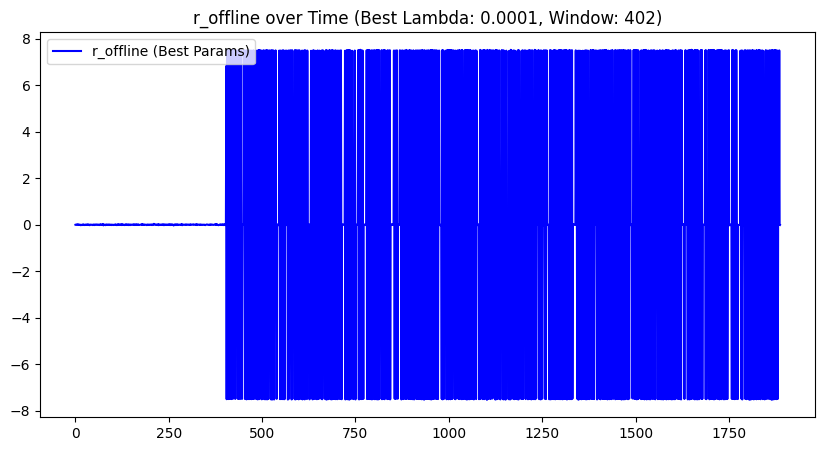

In [ ]:
import optuna
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure your global variables/data are loaded here ---
# e.g., topics, sigma, kappa, w, predictions = load_data()

def objective(trial):
    # 1. Define the search space for your hyperparameters
    # log=True is usually recommended for lambda/penalty parameters
    lambda_lasso = trial.suggest_float("lambda_lasso", 1e-5, 1.0, log=True)
    
    # Adjust the range (min, max) based on your dataset's size
    rolling_window_size = trial.suggest_int("rolling_window_size", 50, 500)
    
    # 2. Run the offline model
    beta_offline, r_offline, n_active = multivariate_CGL_offline_lasso(
        topics, 
        sigma, 
        kappa, 
        w, 
        rolling_window_size=rolling_window_size, 
        lambda_lasso=lambda_lasso, 
        correct_with_tanh=True, 
        random_number=42,
        standardize=True
    )
    
    # 3. Enforce the n_active constraint
    if n_active <= 0:
        # Prune (discard) this trial immediately to save time
        raise optuna.TrialPruned()
        
    # 4. Estimate kappa
    # Note: Ensure 'predictions' is accessible in this scope
    kappa_est, int_est, r2 = estimate_kappa_nls(
        predictions, 
        r_offline, 
        w=w, 
        correct_with_tanh=True
    )
    
    # 5. Define the metric to minimize (absolute error)
    error = abs(kappa - kappa_est)
    
    return error

# --- Set up and run the study ---
print("Starting Optuna optimization...")

# We want to minimize the error difference
study = optuna.create_study(direction="minimize")

# Run the optimization (adjust n_trials to your time constraints)
study.optimize(objective, n_trials=100)

# --- Output the best results ---
print("\n--- Optimization Finished ---")
print("Best Trial:")
best_trial = study.best_trial
print(f"  Error (Diff from True Kappa): {best_trial.value:.4f}")
print("  Best Parameters:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# --- Optional: Run one final time with the best parameters to plot ---
best_lambda = best_trial.params['lambda_lasso']
best_window = best_trial.params['rolling_window_size']

_, best_r_offline, best_n_active = multivariate_CGL_offline_lasso(
    topics, sigma, kappa, w, 
    rolling_window_size=best_window, 
    lambda_lasso=best_lambda, 
    correct_with_tanh=True, 
    random_number=42, standardize=True
)

plt.figure(figsize=(10, 5))
plt.plot(best_r_offline, label='r_offline (Best Params)', color='blue')
plt.title(f'r_offline over Time (Best Lambda: {best_lambda:.4f}, Window: {best_window})')
plt.legend()
plt.show()

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# 0. Identify topic names (assuming 'topics' is a DataFrame)
topic_names = topics.columns.tolist()
warnings.filterwarnings("ignore", category=ConvergenceWarning)
results_list = []

# Loop through random states
for seed in range(5):
    if seed % 1 == 0:
        print(f"Processing random_state {seed} out of 25...")
        
    # 1. Run the offline Lasso model
    beta_offline, r_offline, n_active, predictions = multivariate_CGL_offline_lasso(topics, sigma, kappa, w, rolling_window_size = 20, lambda_lasso =  lambda_lasso, correct_with_tanh=True, random_number=seed)

    
    # Clean the beta matrix (handle nesting/singleton dimensions)
    beta_cleaned = np.squeeze(beta_offline)
    
    # 2. Convert the beta matrix into a named DataFrame
    beta_named_df = pd.DataFrame(beta_cleaned, columns=topic_names)
    
    # 3. Estimate the ALM parameters via NLS
    kappa_est, int_est, r2 = estimate_kappa_nls(predictions, r_offline, w=w, correct_with_tanh=True)

    
    # 4. Append the results
    results_list.append({
        'random_state': seed,
        'n_active_total': n_active,
        'kappa_est': kappa_est,
        'intercept_est': int_est,
        'r2_score': r2,
        # Now storing a named DataFrame instead of a raw array
        'beta_coefficients': beta_named_df, 
        'r_offline': r_offline.copy() 
    })

# 5. Convert to main results DataFrame
results_df = pd.DataFrame(results_list)

print("\nSimulation Complete!")

Processing random_state 0 out of 25...


KeyboardInterrupt: 

In [ ]:
# Get Topic 1 (e.g., 'Natural disasters') from the first run
first_run_betas = results_df['beta_coefficients'].iloc[0]
natural_disasters_series = first_run_betas['Natural disasters']
print(f"Mean Beta for Natural disasters in Run 0: {natural_disasters_series.mean():.6f}")

Mean Beta for Natural disasters in Run 0: 0.008829


In [ ]:
results_df

,random_state,n_active_total,kappa_est,intercept_est,r2_score,beta_coefficients,r_offline
0,0,26262,0.708911,-0.002059,0.730940,Natural disasters Internet Soft drinks...,"[0.0, 0.001257302210933933, -0.001321048632913..."
1,1,26916,0.710637,0.000602,0.727346,Natural disasters Internet Soft drinks...,"[0.0, 0.0034558419206478603, 0.008216181435011..."
2,2,25209,0.711715,-0.000578,0.726690,Natural disasters Internet Soft drinks...,"[0.0, 0.0018905338179353306, -0.00522748441480..."
3,3,2964,0.707168,0.000459,0.697072,Natural disasters Internet Soft drinks...,"[0.0, 0.020409191213851825, -0.025556650313141..."
4,4,22624,0.708707,0.003126,0.716651,Natural disasters Internet Soft drinks...,"[0.0, -0.006517911526116896, -0.00174717292325..."
5,5,19679,0.709085,0.000585,0.723999,Natural disasters Internet Soft drinks...,"[0.0, -0.008019314252534474, -0.01324358995628..."
6,6,17242,0.707695,-0.001318,0.712071,Natural disasters Internet Soft drinks...,"[0.0, 0.010531157544867583, 0.0177649130381699..."
7,7,7847,0.711775,-0.000227,0.703695,Natural disasters Internet Soft drinks...,"[0.0, 1.2301533574825743e-05, 0.00298745537508..."
8,8,18586,0.710410,0.001959,0.720227,Natural disasters Internet Soft drinks...,"[0.0, -0.01738266398496882, -0.013366427931811..."
9,9,22685,0.705519,0.001736,0.739486,Natural disasters Internet Soft drinks...,"[0.0, -0.008028369359828766, 0.002428499070790..."


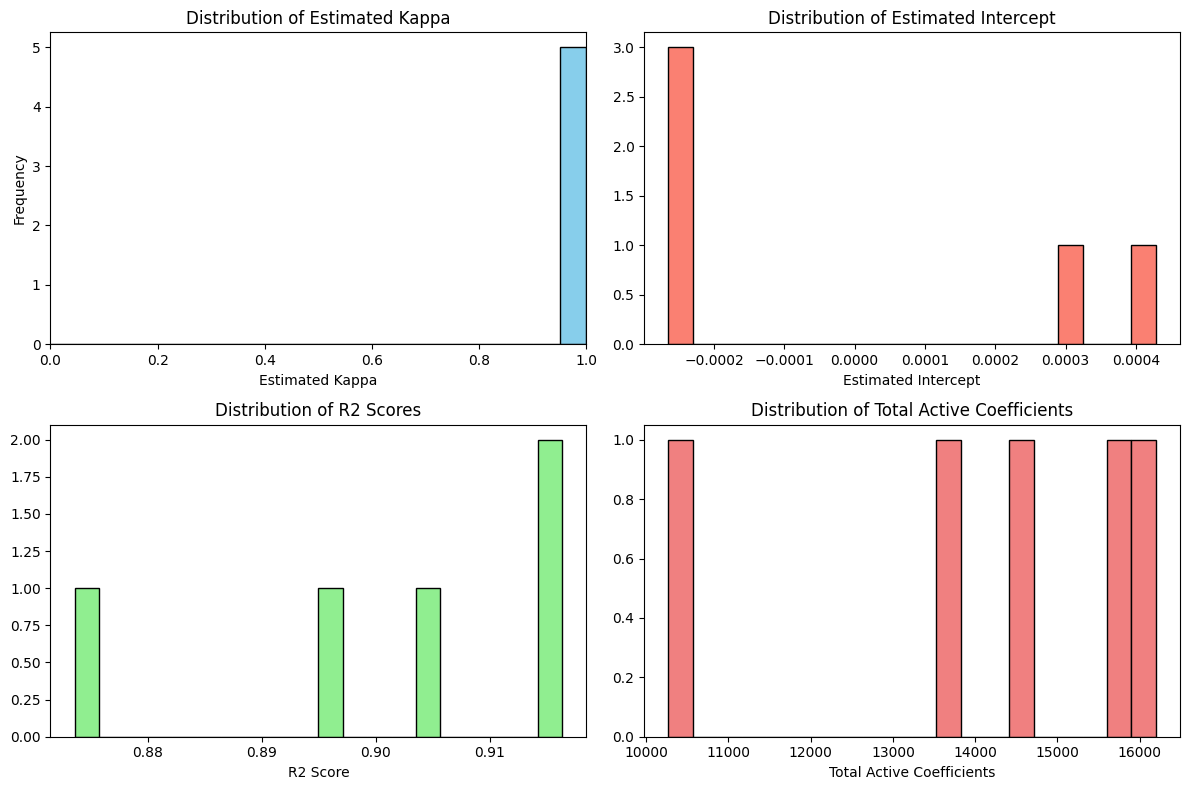

In [ ]:
# plot the results
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(results_df['kappa_est'].dropna(), bins=20, range=(0, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Estimated Kappa')
plt.xlabel('Estimated Kappa')
plt.ylabel('Frequency')
# Set the x-axis limits strictly from 0 to 1
plt.xlim(0, 1)
plt.subplot(2, 2, 2)
plt.hist(results_df['intercept_est'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Estimated Intercept')
plt.xlabel('Estimated Intercept')
plt.subplot(2, 2, 3)
plt.hist(results_df['r2_score'].dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of R2 Scores')
plt.xlabel('R2 Score')
plt.subplot(2, 2, 4)
plt.hist(results_df['n_active_total'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Total Active Coefficients')
plt.xlabel('Total Active Coefficients')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# 1. Convert the list of beta matrices into a 3D NumPy array
# Shape: (n_seeds, n_time_steps, n_topics)
beta_stack = np.array(results_df['beta_coefficients'].tolist())

# Clean up singleton dimensions if the Lasso output had a shape like (T, K, 1)
if beta_stack.ndim > 3:
    beta_stack = beta_stack.squeeze()

# 2. Calculate the count of non-zero occurrences across seeds
# We sum the boolean (beta != 0) along axis 0 (the random seeds axis)
selection_counts = (beta_stack != 0).sum(axis=0)

# 3. Organize into a DataFrame for easy inspection
# Rows = Time Steps, Columns = Topics
selection_counts_df = pd.DataFrame(
    selection_counts, 
    columns=[f'Topic_{i}' for i in range(selection_counts.shape[1])]
)

# 4. Optional: Add a 'Time_Step' index or column if you have dates
selection_counts_df.index.name = 'Time_Step'

# Display the result


# To see the total selection count across all time and all seeds for each topic:
print("\nTotal 'Active' instances across the entire period per topic:")
print(selection_counts_df.sum())

# out of all cells that are not 0, count the cells that are equal to 10
print("\nCount of cells that are exactly 10 (selected in all runs):")
print((selection_counts_df == 10).sum().sum())


Total 'Active' instances across the entire period per topic:
Topic_0      78
Topic_1      18
Topic_2       3
Topic_3      15
Topic_4      75
             ..
Topic_175     6
Topic_176    30
Topic_177    99
Topic_178    57
Topic_179    24
Length: 180, dtype: int64

Count of cells that are exactly 10 (selected in all runs):
0


C:\Users\jonat\AppData\Local\Temp\ipykernel_39848\759244814.py:16: RuntimeWarning: Mean of empty slice
  mean_beta_active = np.nanmean(beta_temp, axis=0)
c:\Users\jonat\anaconda3\envs\reddit_env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


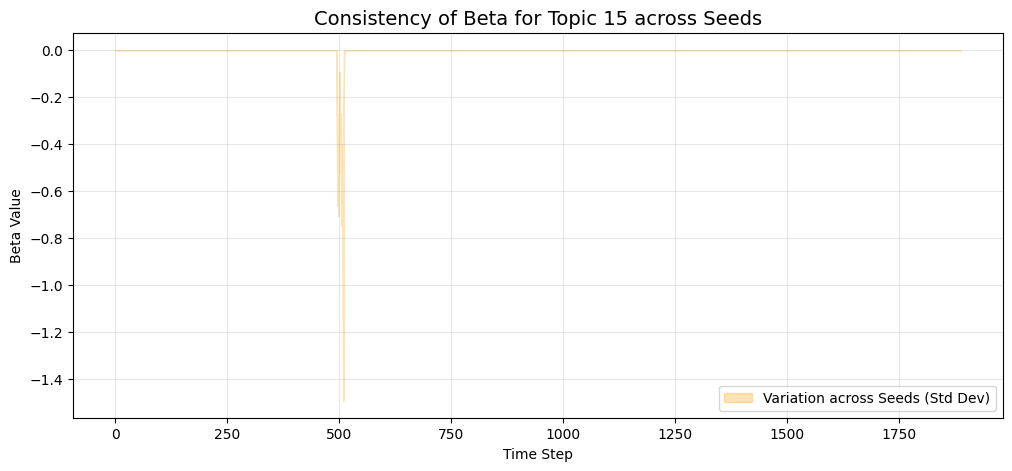

Max variation (Std Dev) for Topic 15: 0.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare and Squeeze the stack
beta_stack = np.array(results_df['beta_coefficients'].tolist())
# This removes any singleton dimensions (like the '1' in (20, T, K, 1))
beta_stack = np.squeeze(beta_stack)

# 2. Identify where topics were selected
# Replace zeros with NaN so they don't bias the Mean/Std Dev
beta_temp = beta_stack.copy().astype(float)
beta_temp[beta_temp == 0] = np.nan

# 3. Calculate Mean and Std across seeds (axis 0)
mean_beta_active = np.nanmean(beta_temp, axis=0)
std_beta_active = np.nanstd(beta_temp, axis=0)

# 4. Plotting for Topic 1
topic_idx = 15

# Extract the 1D arrays for the specific topic
# We use .flatten() just in case there are hidden dimensions
x = np.arange(mean_beta_active.shape[0])
y_mean = mean_beta_active[:, topic_idx].flatten()
y_std = std_beta_active[:, topic_idx].flatten()

# Fill NaNs with 0 for the plot so it doesn't break the line
y_mean_plot = np.nan_to_num(y_mean)
y_std_plot = np.nan_to_num(y_std)

plt.figure(figsize=(12, 5))

# Plot the mean line


# Plot the variation band (Std Dev)
# This will show you exactly if/how much the coefficient differs across runs
plt.fill_between(
    x, 
    y_mean_plot - y_std_plot, 
    y_mean_plot + y_std_plot, 
    alpha=0.3, 
    color='orange', 
    label='Variation across Seeds (Std Dev)'
)

plt.title(f'Consistency of Beta for Topic {topic_idx} across Seeds', fontsize=14)
plt.ylabel('Beta Value')
plt.xlabel('Time Step')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quick check: 
print(f"Max variation (Std Dev) for Topic {topic_idx}: {np.nanmax(y_std):.6f}")

After simulating data, we feed the same data into our empirircal code.

------------------------------
RESULTS FOR RUN 0 (Random State: 0)
------------------------------
R² Score:          -0.000000
Kappa (Estimated): 0.000000
Intercept:         0.000449
Total Active:      2820


Text(0.5, 1.0, 'r_offline over Time for Run 0')

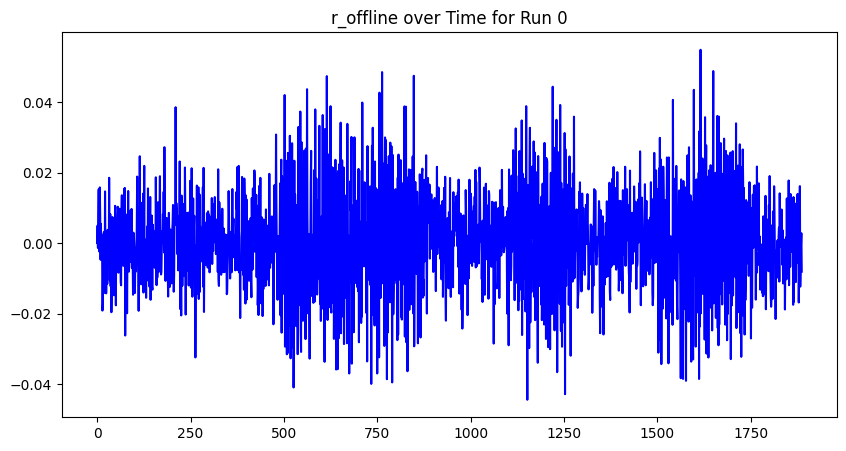

In [ ]:
# 1. Extract the first row as a Series
first_run = results_df.iloc[0]
r_offline_0 = first_run['r_offline']


# 2. Print scalar metrics and parameters
print("-" * 30)
print(f"RESULTS FOR RUN 0 (Random State: {first_run['random_state']})")
print("-" * 30)
print(f"R² Score:          {first_run['r2_score']:.6f}")
print(f"Kappa (Estimated): {first_run['kappa_est']:.6f}")
print(f"Intercept:         {first_run['intercept_est']:.6f}")
print(f"Total Active:      {first_run['n_active_total']}")

# plot r_offline for the first run
plt.figure(figsize=(10, 5))
plt.plot(r_offline_0, label='r_offline (Run 0)', color='blue')
plt.title('r_offline over Time for Run 0')

In [ ]:
results = estimate_single_config_fast(topics, r_offline_0, window_size = 20, n_lags = 1, lambda_val = lambda_lasso, standardize=True, verbose=False, save_only_positve_r_squared = False, return_details=True)

In [ ]:
# get betas from empirical run
beta_columns = [col for col in results['details'].columns if col.startswith('Lasso_')]
betas_empirical = results['details'][beta_columns].values
betas_empirical = np.squeeze(betas_empirical)

In [ ]:
# 1. Extract the simulated betas from Run 0
# We use .iloc[0] and convert to NumPy to match the empirical data type
sim_betas_raw = results_df['beta_coefficients'].iloc[0].values 

# 2. Align Lengths (Trimming the simulated betas to match the empirical length)
# Assuming the empirical betas start after the first rolling window
if sim_betas_raw.shape[0] > betas_empirical.shape[0]:
    # Calculate the offset (should be 20)
    offset = sim_betas_raw.shape[0] - betas_empirical.shape[0]
    sim_betas_aligned = sim_betas_raw[offset:, :]
else:
    sim_betas_aligned = sim_betas_raw

# 3. Final Conversion and Shape Squeeze
# This ensures both are <class 'numpy.ndarray'> with shape (1868, 180)
sim_betas_final = np.ascontiguousarray(sim_betas_aligned)
emp_betas_final = np.ascontiguousarray(betas_empirical)

total_corr = np.corrcoef(emp_betas_final.flatten(), sim_betas_final.flatten())[0, 1]
print(f"Overall Correlation: {total_corr:.6f}")

# 1. Create masks for non-zero values in both arrays
mask_empirical = (emp_betas_final != 0)
mask_simulated = (sim_betas_final != 0)

# 2. Find cells where both masks are True (Logical AND)
both_nonzero = np.logical_and(mask_empirical, mask_simulated)

# 3. Calculate counts
count_emp = np.sum(mask_empirical)
count_sim = np.sum(mask_simulated)
count_overlap = np.sum(both_nonzero)

# 4. Calculate percentage of overlap (Jaccard-style)
union_nonzero = np.logical_or(mask_empirical, mask_simulated)
jaccard_similarity = count_overlap / np.sum(union_nonzero)

print(f"--- Non-Zero Cell Analysis ---")
print(f"Non-zero cells in Empirical: {count_emp}")
print(f"Non-zero cells in Simulated: {count_sim}")
print(f"Cells non-zero in BOTH:      {count_overlap}")
print(f"Intersection over Union:     {jaccard_similarity:.4%}")

# 5. Check for exact matches (including the specific coefficient values)
exact_matches = np.isclose(emp_betas_final, sim_betas_final, atol=1e-8)
print(f"Total exactly matching cells: {np.sum(exact_matches)} out of {emp_betas_final.size}")

Overall Correlation: 1.000000
--- Non-Zero Cell Analysis ---
Non-zero cells in Empirical: 2820
Non-zero cells in Simulated: 2820
Cells non-zero in BOTH:      2820
Intersection over Union:     100.0000%
Total exactly matching cells: 336240 out of 336240


In [ ]:
import pandas as pd

# Data structures to hold the results
records = []

# Loop through the first 10 topics
for i in range(180):
    # Find indices where values are non-zero
    emp_nonzero_indices = np.where(emp_betas_final[:, i] != 0)[0]
    sim_nonzero_indices = np.where(sim_betas_final[:, i] != 0)[0]
    
    # Create a summary string of the first 5 dates for display
    emp_sample = ", ".join(map(str, emp_nonzero_indices[:5])) + ("..." if len(emp_nonzero_indices) > 5 else "")
    sim_sample = ", ".join(map(str, sim_nonzero_indices[:5])) + ("..." if len(sim_nonzero_indices) > 5 else "")
    
    records.append({
        "Topic Index": i,
        "Empirical Total Active": len(emp_nonzero_indices),
        "Empirical First Dates": emp_sample,
        "Simulated Total Active": len(sim_nonzero_indices),
        "Simulated First Dates": sim_sample
    })

# Create DataFrame
nonzero_table = pd.DataFrame(records)

# Display the table
print("--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---")
# loop and print each row with better formatting
for idx, row in nonzero_table.iterrows():
    print(f"Topic {row['Topic Index']}: Empirical Active={row['Empirical Total Active']} (Dates: {row['Empirical First Dates']}), "
          f"Simulated Active={row['Simulated Total Active']} (Dates: {row['Simulated First Dates']})")

--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---
Topic 0: Empirical Active=26 (Dates: 623, 1537, 1539, 1540, 1584...), Simulated Active=26 (Dates: 623, 1537, 1539, 1540, 1584...)
Topic 1: Empirical Active=6 (Dates: 1545, 1546, 1547, 1630, 1631...), Simulated Active=6 (Dates: 1545, 1546, 1547, 1630, 1631...)
Topic 2: Empirical Active=1 (Dates: 1151), Simulated Active=1 (Dates: 1151)
Topic 3: Empirical Active=5 (Dates: 760, 762, 763, 764, 836), Simulated Active=5 (Dates: 760, 762, 763, 764, 836)
Topic 4: Empirical Active=25 (Dates: 1132, 1133, 1134, 1138, 1139...), Simulated Active=25 (Dates: 1132, 1133, 1134, 1138, 1139...)
Topic 5: Empirical Active=3 (Dates: 1613, 1679, 1681), Simulated Active=3 (Dates: 1613, 1679, 1681)
Topic 6: Empirical Active=15 (Dates: 204, 537, 538, 539, 540...), Simulated Active=15 (Dates: 204, 537, 538, 539, 540...)
Topic 7: Empirical Active=1 (Dates: 646), Simulated Active=1 (Dates: 646)
Topic 8: Empirical Active=4 (Dates: 803, 1194, 11